# BiLSTM Transfer Learning: Sentiment140 -> HateXplain

This notebook focuses on a custom transfer approach:
1. Pretrain a custom BiLSTM on Sentiment140 (binary sentiment).
2. Fine-tune the custom BiLSTM on HateXplain (3 classes).

It reports pre-finetune and post-finetune performance on HateXplain, with optional BERT comparison.

In [6]:
# Install missing dependencies (safe for Colab).
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = [
    "kagglehub",
    "datasets",
    "seaborn",
    "scikit-learn",
    "gensim",
    "transformers",
    "accelerate",
]

for pkg in REQUIRED_PACKAGES:
    try:
        importlib.import_module(pkg.replace("-", "_"))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dependency check complete.")

Dependency check complete.


In [7]:
# Mount Google Drive when running in Colab.
# Artifacts (checkpoints/final model) will be saved to Drive if mounted.
from pathlib import Path
import os
import sys

DRIVE_ARTIFACT_DIR = None

if "google.colab" in sys.modules:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DRIVE_ARTIFACT_DIR = Path("/content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts")
    DRIVE_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Google Drive mounted. Artifact directory: {DRIVE_ARTIFACT_DIR}")
else:
    print("Not running in Colab. Using local artifact directory unless ARTIFACT_DIR env var is set.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Artifact directory: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts


In [8]:
import copy
import hashlib
import os
import random
import re
import json
import urllib.request

from collections import Counter
from pathlib import Path

import inspect
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from datasets import Dataset as HFDataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)


# -------------------------
# Global config
# -------------------------
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SENTIMENT140_SAMPLE_SIZE = 200_000
S140_VALID_SIZE = 0.10

MAX_VOCAB = 50_000
MIN_FREQ = 2
MAX_LEN = 80

EMBED_DIM = 200
HIDDEN_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.50

BATCH_SIZE_PRETRAIN = 256
BATCH_SIZE_FINETUNE = 32

LR_PRETRAIN = 2e-3
LR_STAGE2_EMBED = 5e-5
LR_STAGE2_LSTM = 1e-4
LR_STAGE2_HEAD = 7e-4
WEIGHT_DECAY = 5e-4

EPOCHS_PRETRAIN = 7
EPOCHS_FINETUNE = 12
PATIENCE_PRETRAIN = 2
PATIENCE_FINETUNE = 4
FREEZE_ENCODER_EPOCHS = 1
STAGE2_LABEL_SMOOTHING = 0.05

USE_PRETRAINED_GLOVE = True
GLOVE_MODEL_NAME = "glove-twitter-200"
USE_WEIGHTED_SAMPLER = True
LOAD_STAGE1_ENCODER = True

RUN_BERT = True
BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LEN = 128
BERT_BATCH_SIZE = 16
BERT_LR = 2e-5
BERT_WEIGHT_DECAY = 0.01
BERT_EPOCHS = 4

DEFAULT_ARTIFACT_DIR = DRIVE_ARTIFACT_DIR if "DRIVE_ARTIFACT_DIR" in globals() and DRIVE_ARTIFACT_DIR else Path("artifacts")
ARTIFACT_DIR = Path(os.environ.get("ARTIFACT_DIR", str(DEFAULT_ARTIFACT_DIR)))
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_CACHE_DIR = ARTIFACT_DIR / "glove_cache"
GLOVE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
GENSIM_DATA_DIR = GLOVE_CACHE_DIR / "gensim_data"
GENSIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
os.environ["GENSIM_DATA_DIR"] = str(GENSIM_DATA_DIR)

import gensim.downloader as api

MODEL_NAME_CUSTOM_BILSTM = "custom-bilstm"
MODEL_NAME_BERT = "bert-base"


CANONICAL_TO_ID = {
    "normal": 0,
    "hatespeech": 1,
    "offensive": 2,
}
ID_TO_LABEL = {
    0: "normal",
    1: "hate speech",
    2: "offensive",
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"GloVe cache directory: {GLOVE_CACHE_DIR}")
print(f"Gensim data directory: {GENSIM_DATA_DIR}")

Device: cuda
Artifact directory: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts
GloVe cache directory: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/glove_cache
Gensim data directory: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/glove_cache/gensim_data


In [9]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"https?://\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"@\w+", " <user> ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z0-9<>'!?.,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _find_sentiment140_csv(root_dir: Path) -> Path:
    candidate_names = [
        "training.1600000.processed.noemoticon.csv",
        "testdata.manual.2009.06.14.csv",
    ]
    for name in candidate_names:
        hits = list(root_dir.rglob(name))
        if hits:
            return hits[0]

    all_csv = list(root_dir.rglob("*.csv"))
    if all_csv:
        return all_csv[0]

    raise FileNotFoundError("No CSV file found for Sentiment140.")


def load_sentiment140(sample_size: int = 200_000) -> pd.DataFrame:
    """Load Sentiment140 and return DataFrame with columns: text, label."""
    try:
        ds_dir = Path(kagglehub.dataset_download("kazanova/sentiment140"))
    except Exception as exc:
        raise RuntimeError(
            "Failed to download Sentiment140. In Colab, configure Kaggle credentials first "
            "(kaggle.json or KAGGLE_USERNAME/KAGGLE_KEY)."
        ) from exc

    csv_path = _find_sentiment140_csv(ds_dir)
    df = pd.read_csv(
        csv_path,
        encoding="latin-1",
        header=None,
        names=["target", "id", "date", "flag", "user", "text"],
    )

    df = df[df["target"].isin([0, 4])].copy()
    df["label"] = df["target"].map({0: 0, 4: 1}).astype(int)
    df["text"] = df["text"].astype(str).map(clean_text)
    df = df[df["text"].str.len() > 0].reset_index(drop=True)

    if sample_size and sample_size < len(df):
        splitter = StratifiedShuffleSplit(
            n_splits=1,
            train_size=sample_size,
            random_state=SEED,
        )
        sample_idx, _ = next(splitter.split(df["text"], df["label"]))
        df = df.iloc[sample_idx].reset_index(drop=True)

    return df[["text", "label"]]


def _normalize_hatexplain_label(raw_label: str) -> str | None:
    key = str(raw_label).strip().lower().replace("_", "").replace(" ", "")
    label_map = {
        "normal": "normal",
        "nonoffensive": "normal",
        "none": "normal",
        "hatespeech": "hatespeech",
        "hate": "hatespeech",
        "offensive": "offensive",
        "abusive": "offensive",
    }
    return label_map.get(key)


def _majority_vote(labels: list[str]) -> str | None:
    counts = Counter(labels)
    label, count = counts.most_common(1)[0]
    return label if count >= 2 else None


def load_hatexplain_majority() -> pd.DataFrame:
    """Load HateXplain directly from JSON files to bypass HuggingFace script restrictions."""
    print("Downloading HateXplain dataset directly from GitHub...")
    dataset_url = "https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/dataset.json"
    splits_url = "https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/post_id_divisions.json"
    
    # Fetch the raw JSON data
    with urllib.request.urlopen(dataset_url) as url:
        data = json.loads(url.read().decode())
        
    with urllib.request.urlopen(splits_url) as url:
        splits = json.loads(url.read().decode())
        
    # Map post IDs to their respective splits (train, validation, test)
    id_to_split = {}
    for split_name, ids in splits.items():
        # Convert 'val' to 'validation'
        normalized_split = "validation" if split_name == "val" else split_name
        for post_id in ids:
            id_to_split[post_id] = normalized_split

    rows = []
    for post_id, item in data.items():
        tokens = item.get("post_tokens", [])
        text = " ".join(tokens)
        text = clean_text(text)
        if not text:
            continue
            
        annotators = item.get("annotators", [])
        raw_labels = [ann.get("label") for ann in annotators if "label" in ann]
        if not raw_labels:
            continue
            
        normalized_labels = []
        for raw in raw_labels:
            canon = _normalize_hatexplain_label(str(raw))
            if canon is not None:
                normalized_labels.append(canon)
                
        if not normalized_labels:
            continue
            
        majority = _majority_vote(normalized_labels)
        if majority is None:
            continue
        rows.append(
            {
                "text": text,
                "label": CANONICAL_TO_ID[majority],
                "split": id_to_split.get(post_id, "train"),
            }
        )

    out_df = pd.DataFrame(rows)
    if out_df.empty:
        raise RuntimeError("No valid HateXplain samples were parsed.")

    return out_df

In [10]:
def build_vocab(texts, min_freq=2, max_vocab=50_000):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, freq in counter.most_common():
        if freq < min_freq or len(vocab) >= max_vocab:
            break
        vocab[token] = len(vocab)

    return vocab


def load_glove_embeddings(vocab, embed_dim=200, model_name="glove-twitter-200"):
    token_signature = hashlib.sha1("\n".join(vocab.keys()).encode("utf-8")).hexdigest()[:12]
    safe_model_name = model_name.replace("/", "_").replace("-", "_")
    cache_path = GLOVE_CACHE_DIR / f"{safe_model_name}_d{embed_dim}_{token_signature}.npy"

    if cache_path.exists():
        print(f"Loading cached embedding matrix: {cache_path}")
        matrix = np.load(cache_path)
        return torch.tensor(matrix, dtype=torch.float)

    print(f"Loading pretrained embeddings: {model_name}")
    print(f"Using gensim cache directory: {os.environ.get('GENSIM_DATA_DIR')}")
    glove = api.load(model_name)

    matrix = np.random.normal(0, 0.6, (len(vocab), embed_dim)).astype(np.float32)
    matrix[vocab["<pad>"]] = 0.0
    found = 0

    for token, idx in vocab.items():
        if token in {"<pad>", "<unk>"}:
            continue
        if token in glove:
            matrix[idx] = glove[token]
            found += 1

    np.save(cache_path, matrix)
    print(f"Saved embedding cache: {cache_path}")
    print(f"Embedding coverage: {found}/{len(vocab)} = {found / len(vocab):.2%}")
    return torch.tensor(matrix, dtype=torch.float)


def build_weighted_sampler(labels):
    label_counts = Counter(labels)
    sample_weights = [1.0 / label_counts[label] for label in labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def encode_texts(texts, vocab, max_len):
    pad_id = vocab["<pad>"]
    unk_id = vocab["<unk>"]

    input_ids = np.full((len(texts), max_len), pad_id, dtype=np.int64)
    lengths = np.zeros(len(texts), dtype=np.int64)

    for i, text in enumerate(texts):
        tokens = str(text).split()
        ids = [vocab.get(tok, unk_id) for tok in tokens][:max_len]

        if not ids:
            ids = [unk_id]

        seq_len = len(ids)
        input_ids[i, :seq_len] = ids
        lengths[i] = seq_len

    return input_ids, lengths


class TextDataset(Dataset):
    def __init__(self, input_ids, lengths, labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.lengths[idx], self.labels[idx]

In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        num_classes: int,
        dropout: float,
        pad_idx: int = 0,
        pretrained_embeddings: torch.Tensor | None = None,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            if pretrained_embeddings.shape != self.embedding.weight.data.shape:
                raise ValueError("Pretrained embedding shape does not match model embedding shape.")
            self.embedding.weight.data.copy_(pretrained_embeddings)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 4, num_classes)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, _ = self.lstm(packed)
        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1),
        )
        mask = (torch.arange(output.size(1), device=lengths.device)[None, :] < lengths[:, None]).unsqueeze(-1)
        masked_output = output.masked_fill(~mask, 0.0)
        mean_pool = masked_output.sum(dim=1) / lengths.unsqueeze(1).clamp(min=1).float()
        max_pool = output.masked_fill(~mask, float("-inf")).max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))
        features = torch.cat([mean_pool, max_pool], dim=1)
        features = self.dropout(features)
        logits = self.classifier(features)
        return logits


def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for input_ids, lengths, labels in dataloader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    return {"loss": avg_loss, "accuracy": acc}


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, lengths, labels in dataloader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    return {"loss": avg_loss, "accuracy": acc, "macro_f1": macro_f1}


def fit_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs,
    patience,
    monitor="val_loss",
    mode=None,
    min_delta=1e-4,
):
    history = []
    if mode is None:
        mode = "min" if monitor == "val_loss" else "max"
    if mode not in {"min", "max"}:
        raise ValueError("mode must be 'min' or 'max'")

    best_score = float("inf") if mode == "min" else float("-inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f} train_acc={row['train_acc']:.4f} | "
            f"val_loss={row['val_loss']:.4f} val_acc={row['val_acc']:.4f} "
            f"val_macro_f1={row['val_macro_f1']:.4f}"
        )

        current = row[monitor]
        improved = (
            current < (best_score - min_delta)
            if mode == "min"
            else current > (best_score + min_delta)
        )
        if improved:
            best_score = current
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history), model


def plot_learning_curves(history_df, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Accuracy")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved learning curves: {save_path}")


def build_stage2_optimizer(model):
    return torch.optim.AdamW(
        [
            {"params": model.embedding.parameters(), "lr": LR_STAGE2_EMBED},
            {"params": model.lstm.parameters(), "lr": LR_STAGE2_LSTM},
            {"params": model.classifier.parameters(), "lr": LR_STAGE2_HEAD},
        ],
        weight_decay=WEIGHT_DECAY,
    )


def build_stage2_model(stage1_model=None, pretrained_embeddings=None, device=DEVICE):
    model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=3,
        dropout=DROPOUT,
        pad_idx=vocab["<pad>"],
        pretrained_embeddings=pretrained_embeddings,
    ).to(device)
    if LOAD_STAGE1_ENCODER and stage1_model is not None:
        model.embedding.load_state_dict(stage1_model.embedding.state_dict())
        model.lstm.load_state_dict(stage1_model.lstm.state_dict())
    return model


def evaluate_model(model, dataloader, label_names, device=DEVICE):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, lengths, labels in dataloader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            logits = model(input_ids, lengths)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("HateXplain Test Confusion Matrix")
    plt.show()

    metrics = {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
        "classification_report": report_dict,
    }

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    return metrics

In [12]:
# -------------------------
# Shared evaluation helpers
# -------------------------
BINARY_ID_TO_LABEL = {
    0: "normal",
    1: "toxic",
}

EXPERIMENT_RESULTS = []


def project_hatexplain_to_binary(labels):
    labels = np.asarray(labels, dtype=np.int64)
    return np.where(labels == 0, 0, 1).astype(np.int64)


def evaluate_label_predictions(y_true, y_pred, label_names, title, cmap="Blues"):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)

    labels = list(range(len(label_names)))
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

    metrics = {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
        "classification_report": report_dict,
    }

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    return metrics


def collect_model_predictions(model, dataloader, device=DEVICE):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, lengths, labels in dataloader:
            input_ids = input_ids.to(device)
            lengths = lengths.to(device)

            logits = model(input_ids, lengths)
            preds = torch.argmax(logits, dim=1).cpu().numpy().astype(np.int64)

            y_pred.extend(preds.tolist())
            y_true.extend(labels.cpu().numpy().astype(np.int64).tolist())

    return np.asarray(y_true, dtype=np.int64), np.asarray(y_pred, dtype=np.int64)


def evaluate_stage1_on_hatexplain_binary(model, dataloader, device=DEVICE):
    y_true_multi, y_pred_binary = collect_model_predictions(
        model=model,
        dataloader=dataloader,
        device=device,
    )
    y_true_binary = project_hatexplain_to_binary(y_true_multi)

    return evaluate_label_predictions(
        y_true=y_true_binary,
        y_pred=y_pred_binary,
        label_names=[BINARY_ID_TO_LABEL[i] for i in range(2)],
        title=f"{MODEL_NAME_CUSTOM_BILSTM} Stage 1 on HateXplain (Binary Projection)",
        cmap="Oranges",
    )


def upsert_experiment_result(model_name, stage, task, metrics):
    row = {
        "model": model_name,
        "stage": stage,
        "task": task,
        "accuracy": float(metrics.get("accuracy", np.nan)),
        "macro_f1": float(metrics.get("macro_f1", np.nan)),
        "weighted_f1": float(metrics.get("weighted_f1", np.nan)),
    }

    for i, existing in enumerate(EXPERIMENT_RESULTS):
        if (
            existing["model"] == row["model"]
            and existing["stage"] == row["stage"]
            and existing["task"] == row["task"]
        ):
            EXPERIMENT_RESULTS[i] = row
            break
    else:
        EXPERIMENT_RESULTS.append(row)

    return row


def build_comparison_df():
    if not EXPERIMENT_RESULTS:
        return pd.DataFrame(columns=["model", "stage", "task", "accuracy", "macro_f1", "weighted_f1"])

    df = pd.DataFrame(EXPERIMENT_RESULTS)

    model_order = [MODEL_NAME_CUSTOM_BILSTM, MODEL_NAME_BERT]
    extra_models = []
    for model_name in df["model"].tolist():
        if model_name not in model_order and model_name not in extra_models:
            extra_models.append(model_name)
    model_categories = model_order + extra_models

    df["model"] = pd.Categorical(df["model"], categories=model_categories, ordered=True)
    df["stage"] = pd.Categorical(df["stage"], categories=["pre-finetune", "post-finetune"], ordered=True)

    return df.sort_values(["model", "stage", "task"]).reset_index(drop=True)

In [13]:
# -------------------------
# Load and preprocess data
# -------------------------
sent_df = load_sentiment140(SENTIMENT140_SAMPLE_SIZE)
print("Sentiment140 shape:", sent_df.shape)
print(sent_df["label"].value_counts().sort_index())

s_train_df, s_val_df = train_test_split(
    sent_df,
    test_size=S140_VALID_SIZE,
    random_state=SEED,
    stratify=sent_df["label"],
)
s_train_df = s_train_df.reset_index(drop=True)
s_val_df = s_val_df.reset_index(drop=True)

hatexplain_df = load_hatexplain_majority()
print("\nHateXplain shape:", hatexplain_df.shape)
print(hatexplain_df.groupby(["split", "label"]).size())

hx_train_df = hatexplain_df[hatexplain_df["split"] == "train"].reset_index(drop=True)
hx_val_df = hatexplain_df[hatexplain_df["split"].isin(["validation", "val"])]    .reset_index(drop=True)
hx_test_df = hatexplain_df[hatexplain_df["split"] == "test"].reset_index(drop=True)

if len(hx_val_df) == 0:
    hx_train_df, hx_val_df = train_test_split(
        hx_train_df,
        test_size=0.1,
        random_state=SEED,
        stratify=hx_train_df["label"],
    )
    hx_train_df = hx_train_df.reset_index(drop=True)
    hx_val_df = hx_val_df.reset_index(drop=True)

print("\nHateXplain split sizes:")
print("train:", len(hx_train_df), "val:", len(hx_val_df), "test:", len(hx_test_df))


# -------------------------
# Build vocabulary from training text only
# -------------------------
vocab_texts = pd.concat([s_train_df["text"], hx_train_df["text"]], axis=0).tolist()
vocab = build_vocab(vocab_texts, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB)
print("Vocabulary size:", len(vocab))

glove_embeddings = None
if USE_PRETRAINED_GLOVE:
    glove_embeddings = load_glove_embeddings(
        vocab,
        embed_dim=EMBED_DIM,
        model_name=GLOVE_MODEL_NAME,
    )
else:
    print("Using random embedding initialization.")


# -------------------------
# Encode Sentiment140 for stage 1
# -------------------------
s_train_ids, s_train_lens = encode_texts(s_train_df["text"].tolist(), vocab, MAX_LEN)
s_val_ids, s_val_lens = encode_texts(s_val_df["text"].tolist(), vocab, MAX_LEN)

s_train_ds = TextDataset(s_train_ids, s_train_lens, s_train_df["label"].values)
s_val_ds = TextDataset(s_val_ids, s_val_lens, s_val_df["label"].values)

s_train_loader = DataLoader(s_train_ds, batch_size=BATCH_SIZE_PRETRAIN, shuffle=True)
s_val_loader = DataLoader(s_val_ds, batch_size=BATCH_SIZE_PRETRAIN, shuffle=False)


# -------------------------
# Encode HateXplain for stage 2
# -------------------------
hx_train_ids, hx_train_lens = encode_texts(hx_train_df["text"].tolist(), vocab, MAX_LEN)
hx_val_ids, hx_val_lens = encode_texts(hx_val_df["text"].tolist(), vocab, MAX_LEN)
hx_test_ids, hx_test_lens = encode_texts(hx_test_df["text"].tolist(), vocab, MAX_LEN)

hx_train_ds = TextDataset(hx_train_ids, hx_train_lens, hx_train_df["label"].values)
hx_val_ds = TextDataset(hx_val_ids, hx_val_lens, hx_val_df["label"].values)
hx_test_ds = TextDataset(hx_test_ids, hx_test_lens, hx_test_df["label"].values)

hx_train_sampler = build_weighted_sampler(hx_train_df["label"].tolist()) if USE_WEIGHTED_SAMPLER else None
if hx_train_sampler is not None:
    print("Using WeightedRandomSampler for HateXplain fine-tuning.")
hx_train_loader = DataLoader(
    hx_train_ds,
    batch_size=BATCH_SIZE_FINETUNE,
    sampler=hx_train_sampler,
    shuffle=hx_train_sampler is None,
)
hx_val_loader = DataLoader(hx_val_ds, batch_size=BATCH_SIZE_FINETUNE, shuffle=False)
hx_test_loader = DataLoader(hx_test_ds, batch_size=BATCH_SIZE_FINETUNE, shuffle=False)


# Basic pipeline checks
sample_batch = next(iter(s_train_loader))
print("\nStage 1 sample batch shapes:", sample_batch[0].shape, sample_batch[1].shape, sample_batch[2].shape)
print("Stage 1 label range:", int(sample_batch[2].min()), int(sample_batch[2].max()))

sample_batch_hx = next(iter(hx_train_loader))
print("Stage 2 sample batch shapes:", sample_batch_hx[0].shape, sample_batch_hx[1].shape, sample_batch_hx[2].shape)
print("Stage 2 label range:", int(sample_batch_hx[2].min()), int(sample_batch_hx[2].max()))

Using Colab cache for faster access to the 'sentiment140' dataset.
Sentiment140 shape: (200000, 2)
label
0    100000
1    100000
Name: count, dtype: int64

HateXplain shape: (19229, 3)
split       label
test        0         782
            1         594
            2         548
train       0        6251
            1        4748
            2        4384
validation  0         781
            1         593
            2         548
dtype: int64

HateXplain split sizes:
train: 15383 val: 1922 test: 1924
Vocabulary size: 50000
Loading pretrained embeddings: glove-twitter-200
Using gensim cache directory: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/glove_cache/gensim_data
[==================================================] 100.0% 758.5/758.5MB downloaded
Saved embedding cache: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/glove_cache/glove_twitter_200_d200_66eef672da21.npy
Embedding coverage: 27465/50000 = 54.93%
Using WeightedRandomSampler for HateXplain

## Custom BiLSTM Transfer (Sentiment140 -> HateXplain)

This section trains and evaluates the custom BiLSTM transfer pipeline.

Epoch 01 | train_loss=0.4538 train_acc=0.7830 | val_loss=0.4144 val_acc=0.8084 val_macro_f1=0.8083
Epoch 02 | train_loss=0.3680 train_acc=0.8357 | val_loss=0.4172 val_acc=0.8074 val_macro_f1=0.8073
Epoch 03 | train_loss=0.2949 train_acc=0.8734 | val_loss=0.4498 val_acc=0.8005 val_macro_f1=0.8005
Early stopping triggered.
Saved Stage 1 checkpoint: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/stage1_sentiment140_bilstm.pt


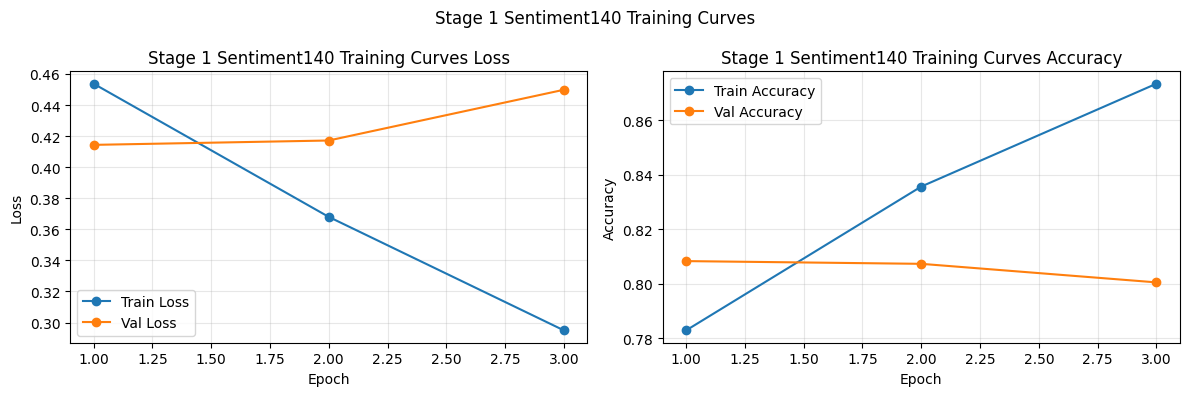

Saved learning curves: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/stage1_learning_curves.png


,epoch,train_loss,train_acc,val_loss,val_acc,val_macro_f1
0,1,0.453752,0.782967,0.414360,0.80835,0.808337
1,2,0.368009,0.835667,0.417168,0.80735,0.807289
2,3,0.294950,0.873356,0.449834,0.80055,0.800531


In [14]:
# -------------------------
# Stage 1: Pretrain on Sentiment140 (2 classes)
# -------------------------
stage1_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=2,
    dropout=DROPOUT,
    pad_idx=vocab["<pad>"],
    pretrained_embeddings=glove_embeddings,
).to(DEVICE)

criterion_stage1 = nn.CrossEntropyLoss()
optimizer_stage1 = torch.optim.AdamW(
    stage1_model.parameters(),
    lr=LR_PRETRAIN,
    weight_decay=WEIGHT_DECAY,
)

stage1_history, stage1_model = fit_with_early_stopping(
    model=stage1_model,
    train_loader=s_train_loader,
    val_loader=s_val_loader,
    optimizer=optimizer_stage1,
    criterion=criterion_stage1,
    device=DEVICE,
    epochs=EPOCHS_PRETRAIN,
    patience=PATIENCE_PRETRAIN,
)

stage1_ckpt = ARTIFACT_DIR / "stage1_sentiment140_bilstm.pt"
torch.save(stage1_model.state_dict(), stage1_ckpt)
print(f"Saved Stage 1 checkpoint: {stage1_ckpt}")

plot_learning_curves(
    stage1_history,
    title="Stage 1 Sentiment140 Training Curves",
    save_path=ARTIFACT_DIR / "stage1_learning_curves.png",
)

stage1_history

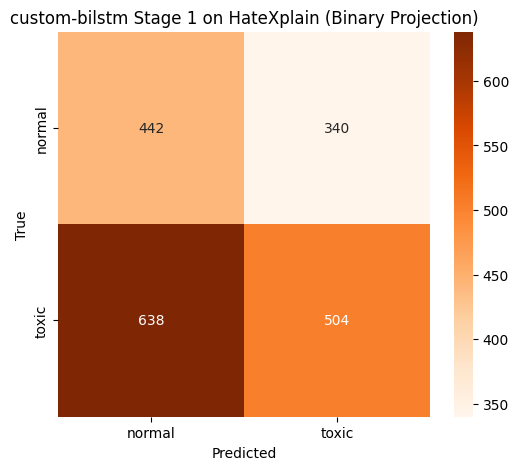

Accuracy: 0.4917
Macro F1: 0.4912
Weighted F1: 0.4942

Stage 1 binary projection report:


,precision,recall,f1-score,support
normal,0.409259,0.565217,0.474758,782.000000
toxic,0.597156,0.441331,0.507553,1142.000000
accuracy,0.491684,0.491684,0.491684,0.491684
macro avg,0.503208,0.503274,0.491156,1924.000000
weighted avg,0.520787,0.491684,0.494224,1924.000000


In [15]:
# -------------------------
# Stage 1 transfer check on HateXplain before fine-tuning
# -------------------------
pt_stage1_pre_metrics = evaluate_stage1_on_hatexplain_binary(
    model=stage1_model,
    dataloader=hx_test_loader,
    device=DEVICE,
)
upsert_experiment_result(MODEL_NAME_CUSTOM_BILSTM, "pre-finetune", "binary-projection", pt_stage1_pre_metrics)

print("\nStage 1 binary projection report:")
pd.DataFrame(pt_stage1_pre_metrics["classification_report"]).T

Loaded pretrained encoder weights into stage 2 model.


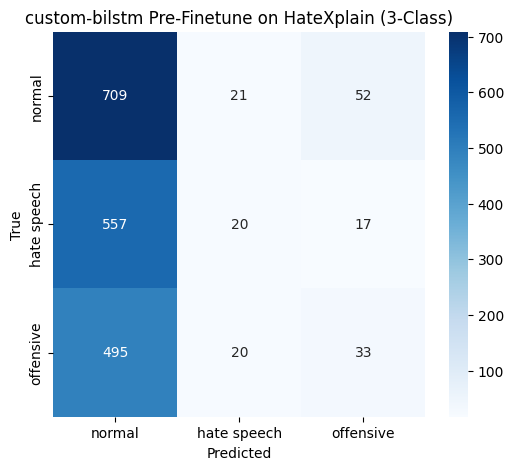

Accuracy: 0.3960
Macro F1: 0.2401
Weighted F1: 0.2744

Pre-finetune 3-class report:
Stage 2 learning rates: {'embedding': 5e-05, 'lstm': 0.0001, 'classifier': 0.0007, 'label_smoothing': 0.05}
Training classifier head with frozen encoder for 1 epoch(s)...
Freeze Epoch 01 | train_loss=1.0582 train_acc=0.4443 | val_loss=1.0297 val_acc=0.4938 val_macro_f1=0.4646
Epoch 01 | train_loss=0.9674 train_acc=0.5383 | val_loss=0.8968 val_acc=0.6139 val_macro_f1=0.5912
Epoch 02 | train_loss=0.8724 train_acc=0.6155 | val_loss=0.8601 val_acc=0.6348 val_macro_f1=0.6343
Epoch 03 | train_loss=0.8272 train_acc=0.6434 | val_loss=0.8421 val_acc=0.6472 val_macro_f1=0.6444
Epoch 04 | train_loss=0.7992 train_acc=0.6637 | val_loss=0.8186 val_acc=0.6582 val_macro_f1=0.6380
Epoch 05 | train_loss=0.7729 train_acc=0.6824 | val_loss=0.8109 val_acc=0.6675 val_macro_f1=0.6631
Epoch 06 | train_loss=0.7561 train_acc=0.6947 | val_loss=0.8081 val_acc=0.6634 val_macro_f1=0.6584
Epoch 07 | train_loss=0.7425 train_acc=0.7042

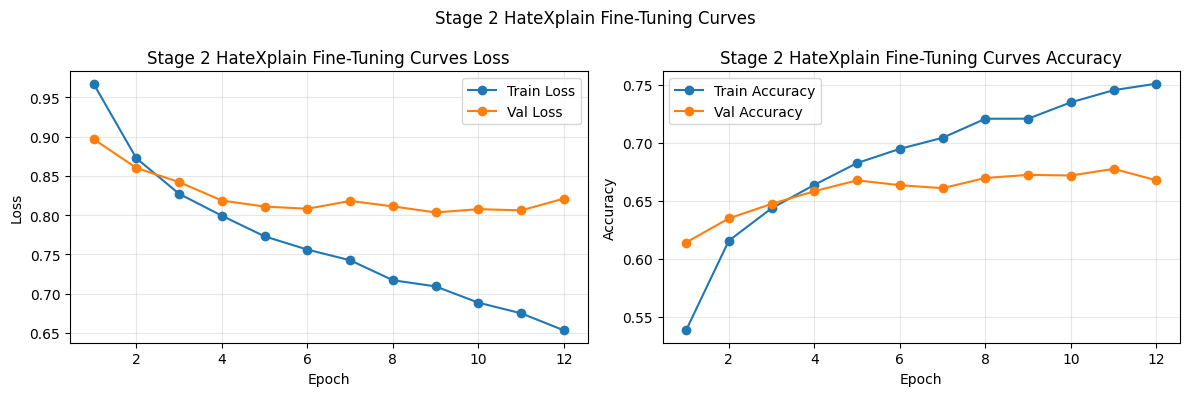

Saved learning curves: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/stage2_learning_curves.png


,epoch,train_loss,train_acc,val_loss,val_acc,val_macro_f1
0,1,0.967428,0.538257,0.896839,0.613944,0.591194
1,2,0.872440,0.615550,0.860106,0.634755,0.634291
2,3,0.827159,0.643438,0.842069,0.647242,0.644444
3,4,0.799180,0.663655,0.818555,0.658169,0.637981
4,5,0.772948,0.682442,0.810887,0.667534,0.663149
5,6,0.756052,0.694663,0.808088,0.663371,0.658402
6,7,0.742455,0.704219,0.818056,0.660770,0.661660
7,8,0.717059,0.720601,0.811097,0.669615,0.665348
8,9,0.709175,0.720666,0.803399,0.672216,0.665150
9,10,0.688431,0.734772,0.807562,0.671696,0.665009


In [16]:
# -------------------------
# Stage 2: Fine-tune on HateXplain (3 classes)
# -------------------------
stage2_model = build_stage2_model(
    stage1_model=stage1_model,
    pretrained_embeddings=glove_embeddings,
    device=DEVICE,
)

if LOAD_STAGE1_ENCODER:
    print("Loaded pretrained encoder weights into stage 2 model.")
else:
    print("Skipping Sentiment140 encoder transfer. Stage 2 starts from GloVe/random embeddings.")

# Stage 1 transfer baseline on the 3-class target before any stage-2 training.
label_names = [ID_TO_LABEL[i] for i in range(3)]
pre_stage2_true, pre_stage2_pred = collect_model_predictions(
    model=stage2_model,
    dataloader=hx_test_loader,
    device=DEVICE,
)
pre_stage2_metrics = evaluate_label_predictions(
    y_true=pre_stage2_true,
    y_pred=pre_stage2_pred,
    label_names=label_names,
    title=f"{MODEL_NAME_CUSTOM_BILSTM} Pre-Finetune on HateXplain (3-Class)",
    cmap="Blues",
)
upsert_experiment_result(MODEL_NAME_CUSTOM_BILSTM, "pre-finetune", "3-class", pre_stage2_metrics)
print("\nPre-finetune 3-class report:")
pd.DataFrame(pre_stage2_metrics["classification_report"]).T

criterion_stage2 = nn.CrossEntropyLoss(label_smoothing=STAGE2_LABEL_SMOOTHING)
print(
    "Stage 2 learning rates:",
    {
        "embedding": LR_STAGE2_EMBED,
        "lstm": LR_STAGE2_LSTM,
        "classifier": LR_STAGE2_HEAD,
        "label_smoothing": STAGE2_LABEL_SMOOTHING,
    },
)

# Optional short warm-up with frozen encoder.
if FREEZE_ENCODER_EPOCHS > 0:
    for p in stage2_model.embedding.parameters():
        p.requires_grad = False
    for p in stage2_model.lstm.parameters():
        p.requires_grad = False

    freeze_optimizer = torch.optim.AdamW(
        [{"params": stage2_model.classifier.parameters(), "lr": LR_STAGE2_HEAD}],
        weight_decay=WEIGHT_DECAY,
    )

    print(f"Training classifier head with frozen encoder for {FREEZE_ENCODER_EPOCHS} epoch(s)...")
    for ep in range(FREEZE_ENCODER_EPOCHS):
        tr = train_one_epoch(stage2_model, hx_train_loader, freeze_optimizer, criterion_stage2, DEVICE)
        va = validate_one_epoch(stage2_model, hx_val_loader, criterion_stage2, DEVICE)
        print(
            f"Freeze Epoch {ep + 1:02d} | "
            f"train_loss={tr['loss']:.4f} train_acc={tr['accuracy']:.4f} | "
            f"val_loss={va['loss']:.4f} val_acc={va['accuracy']:.4f} "
            f"val_macro_f1={va['macro_f1']:.4f}"
        )

    for p in stage2_model.embedding.parameters():
        p.requires_grad = True
    for p in stage2_model.lstm.parameters():
        p.requires_grad = True


optimizer_stage2 = build_stage2_optimizer(stage2_model)

stage2_history, stage2_model = fit_with_early_stopping(
    model=stage2_model,
    train_loader=hx_train_loader,
    val_loader=hx_val_loader,
    optimizer=optimizer_stage2,
    criterion=criterion_stage2,
    device=DEVICE,
    epochs=EPOCHS_FINETUNE,
    patience=PATIENCE_FINETUNE,
    monitor="val_macro_f1",
    mode="max",
    min_delta=1e-3,
)

stage2_ckpt = ARTIFACT_DIR / "stage2_hatexplain_bilstm.pt"
torch.save(stage2_model.state_dict(), stage2_ckpt)
print(f"Saved Stage 2 checkpoint: {stage2_ckpt}")

plot_learning_curves(
    stage2_history,
    title="Stage 2 HateXplain Fine-Tuning Curves",
    save_path=ARTIFACT_DIR / "stage2_learning_curves.png",
)

stage2_history

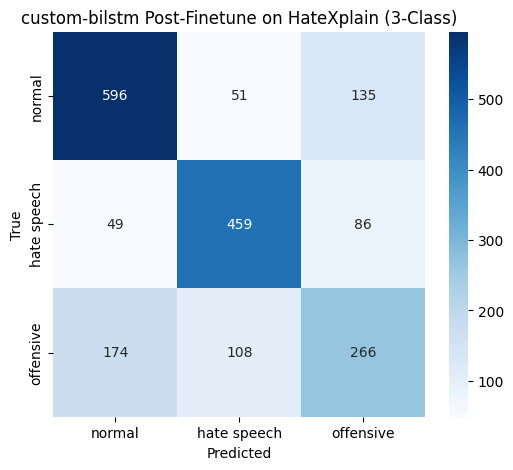

Accuracy: 0.6866
Macro F1: 0.6720
Weighted F1: 0.6829


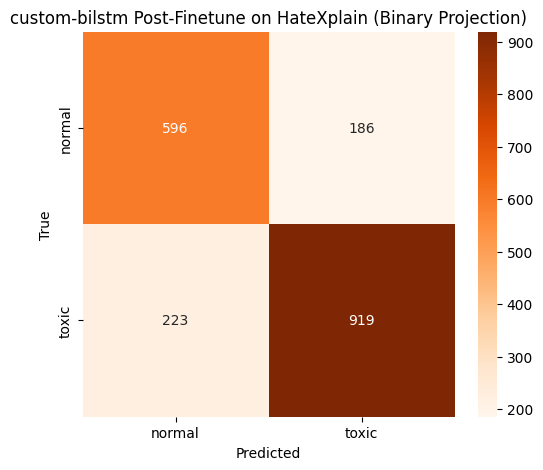

Accuracy: 0.7874
Macro F1: 0.7813
Weighted F1: 0.7881

Per-class report:


,precision,recall,f1-score,support
normal,0.727717,0.762148,0.744535,782.00000
hate speech,0.742718,0.772727,0.757426,594.00000
offensive,0.546201,0.485401,0.514010,548.00000
accuracy,0.686590,0.686590,0.686590,0.68659
macro avg,0.672212,0.673426,0.671990,1924.00000
weighted avg,0.680648,0.686590,0.682856,1924.00000


In [17]:
# -------------------------
# Final evaluation on HateXplain test split
# -------------------------
label_names = [ID_TO_LABEL[i] for i in range(3)]
custom_post_true, custom_post_pred = collect_model_predictions(
    model=stage2_model,
    dataloader=hx_test_loader,
    device=DEVICE,
)

metrics = evaluate_label_predictions(
    y_true=custom_post_true,
    y_pred=custom_post_pred,
    label_names=label_names,
    title=f"{MODEL_NAME_CUSTOM_BILSTM} Post-Finetune on HateXplain (3-Class)",
    cmap="Blues",
)
upsert_experiment_result(MODEL_NAME_CUSTOM_BILSTM, "post-finetune", "3-class", metrics)

custom_post_binary_metrics = evaluate_label_predictions(
    y_true=project_hatexplain_to_binary(custom_post_true),
    y_pred=project_hatexplain_to_binary(custom_post_pred),
    label_names=[BINARY_ID_TO_LABEL[i] for i in range(2)],
    title=f"{MODEL_NAME_CUSTOM_BILSTM} Post-Finetune on HateXplain (Binary Projection)",
    cmap="Oranges",
)
upsert_experiment_result(
    MODEL_NAME_CUSTOM_BILSTM,
    "post-finetune",
    "binary-projection",
    custom_post_binary_metrics,
)

print("\nPer-class report:")
pd.DataFrame(metrics["classification_report"]).T

In [37]:
def predict_text(text: str, model, vocab, max_len=MAX_LEN, device=DEVICE):
    model.eval()
    cleaned = clean_text(text)
    ids, lens = encode_texts([cleaned], vocab, max_len)

    input_ids = torch.tensor(ids, dtype=torch.long).to(device)
    lengths = torch.tensor(lens, dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))
    return {
        "text": text,
        "cleaned_text": cleaned,
        "predicted_label": ID_TO_LABEL[pred_id],
        "probabilities": {ID_TO_LABEL[i]: float(probs[i]) for i in range(len(probs))},
    }


# Smoke test inference
samples = [
    "I appreciate your help today.",
    "You are so dumb and useless.",
    "People like you should be removed from this country.",
]

for s in samples:
    out = predict_text(s, stage2_model, vocab)
    print("\nInput:", out["text"])
    print("Prediction:", out["predicted_label"])
    print("Probabilities:", out["probabilities"])


# Save final deployable artifact (model state + vocab + config)
final_artifact = ARTIFACT_DIR / "bilstm_transfer_hatexplain_artifact.pt"
torch.save(
    {
        "model_state_dict": stage2_model.state_dict(),
        "vocab": vocab,
        "config": {
            "max_len": MAX_LEN,
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "num_layers": NUM_LAYERS,
            "dropout": DROPOUT,
            "label_map": ID_TO_LABEL,
        },
    },
    final_artifact,
)
print(f"\nSaved final artifact: {final_artifact}")


Input: I appreciate your help today.
Prediction: normal
Probabilities: {'normal': 0.6952064037322998, 'hate speech': 0.2398136556148529, 'offensive': 0.06497994810342789}

Input: You are so dumb and useless.
Prediction: offensive
Probabilities: {'normal': 0.2990211844444275, 'hate speech': 0.10126953572034836, 'offensive': 0.5997092723846436}

Input: People like you should be removed from this country.
Prediction: offensive
Probabilities: {'normal': 0.3189728558063507, 'hate speech': 0.172774538397789, 'offensive': 0.5082525610923767}

Saved final artifact: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/bilstm_transfer_hatexplain_artifact.pt


## BERT Comparison

The cells below fine-tune a BERT classifier directly on HateXplain to compare a transformer model against the BiLSTM pipeline.

In [18]:
# -------------------------
# Optional: Fine-tune BERT on HateXplain
# -------------------------
def build_hf_text_dataset(df, tokenizer, max_len):
    frame = df[["text", "label"]].rename(columns={"label": "labels"}).copy()
    dataset = HFDataset.from_pandas(frame, preserve_index=False)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_len)

    return dataset.map(tokenize_batch, batched=True)


def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(acc),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
    }


bert_results = None
bert_report_df = None
bert_tokenizer = None
bert_model = None
bert_test_output = None

if RUN_BERT:
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    bert_train_ds = build_hf_text_dataset(hx_train_df, bert_tokenizer, BERT_MAX_LEN)
    bert_val_ds = build_hf_text_dataset(hx_val_df, bert_tokenizer, BERT_MAX_LEN)
    bert_test_ds = build_hf_text_dataset(hx_test_df, bert_tokenizer, BERT_MAX_LEN)

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=3,
    )

    training_arg_names = set(inspect.signature(TrainingArguments.__init__).parameters)
    bert_steps_per_epoch = max(1, int(np.ceil(len(bert_train_ds) / BERT_BATCH_SIZE)))
    bert_warmup_steps = max(1, int(0.1 * bert_steps_per_epoch * BERT_EPOCHS))

    bert_training_kwargs = {
        "output_dir": str(ARTIFACT_DIR / "bert_hatexplain"),
        "save_strategy": "epoch",
        "learning_rate": BERT_LR,
        "per_device_train_batch_size": BERT_BATCH_SIZE,
        "per_device_eval_batch_size": BERT_BATCH_SIZE,
        "num_train_epochs": BERT_EPOCHS,
        "weight_decay": BERT_WEIGHT_DECAY,
        "warmup_steps": bert_warmup_steps,
        "logging_steps": 50,
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "save_total_limit": 2,
        "seed": SEED,
    }
    if "evaluation_strategy" in training_arg_names:
        bert_training_kwargs["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in training_arg_names:
        bert_training_kwargs["eval_strategy"] = "epoch"
    if "report_to" in training_arg_names:
        bert_training_kwargs["report_to"] = "none"
    if "fp16" in training_arg_names:
        bert_training_kwargs["fp16"] = torch.cuda.is_available()
    if "do_eval" in training_arg_names:
        bert_training_kwargs["do_eval"] = True

    bert_training_args = TrainingArguments(**bert_training_kwargs)

    trainer_arg_names = set(inspect.signature(Trainer.__init__).parameters)
    bert_trainer_kwargs = {
        "model": bert_model,
        "args": bert_training_args,
        "train_dataset": bert_train_ds,
        "eval_dataset": bert_val_ds,
        "data_collator": DataCollatorWithPadding(tokenizer=bert_tokenizer),
        "compute_metrics": compute_hf_metrics,
    }
    if "tokenizer" in trainer_arg_names:
        bert_trainer_kwargs["tokenizer"] = bert_tokenizer
    elif "processing_class" in trainer_arg_names:
        bert_trainer_kwargs["processing_class"] = bert_tokenizer

    bert_trainer = Trainer(**bert_trainer_kwargs)

    bert_trainer.train()
    bert_results = bert_trainer.evaluate(bert_test_ds)
    bert_test_output = bert_trainer.predict(bert_test_ds)
    bert_trainer.save_model(str(ARTIFACT_DIR / "bert_hatexplain_best"))
    bert_tokenizer.save_pretrained(str(ARTIFACT_DIR / "bert_hatexplain_best"))
else:
    print("RUN_BERT is False. Skipping BERT fine-tuning.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

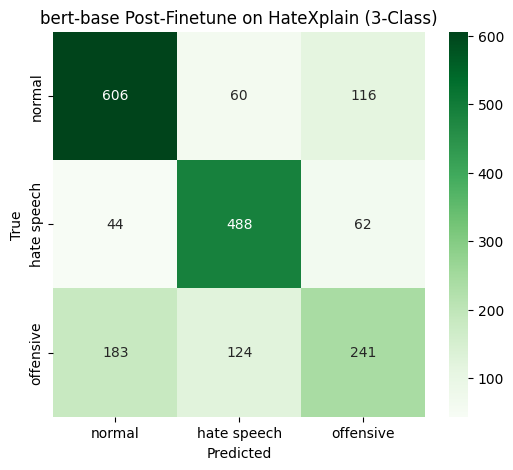

Accuracy: 0.6939
Macro F1: 0.6733
Weighted F1: 0.6850

BERT per-class report:
              precision    recall  f1-score      support
normal         0.727491  0.774936  0.750464   782.000000
hate speech    0.726190  0.821549  0.770932   594.000000
offensive      0.575179  0.439781  0.498449   548.000000
accuracy       0.693867  0.693867  0.693867     0.693867
macro avg      0.676287  0.678755  0.673282  1924.000000
weighted avg   0.683707  0.693867  0.685004  1924.000000


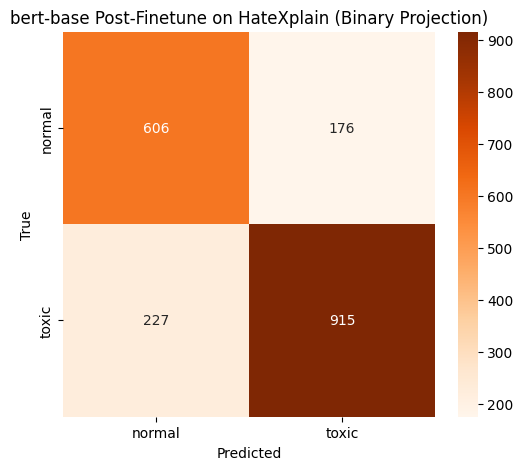

Accuracy: 0.7905
Macro F1: 0.7850
Weighted F1: 0.7915
Saved BERT report: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/bert_post_report.json
Saved BERT report CSV: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/bert_post_report.csv

Model comparison:
           model          stage               task  accuracy  macro_f1  \
0  custom-bilstm   pre-finetune            3-class  0.396050  0.240072   
1  custom-bilstm   pre-finetune  binary-projection  0.491684  0.491156   
2  custom-bilstm  post-finetune            3-class  0.686590  0.671990   
3  custom-bilstm  post-finetune  binary-projection  0.787422  0.781257   
4      bert-base  post-finetune            3-class  0.693867  0.673282   
5      bert-base  post-finetune  binary-projection  0.790541  0.784995   

   weighted_f1  
0     0.274412  
1     0.494224  
2     0.682856  
3     0.788128  
4     0.685004  
5     0.791456  


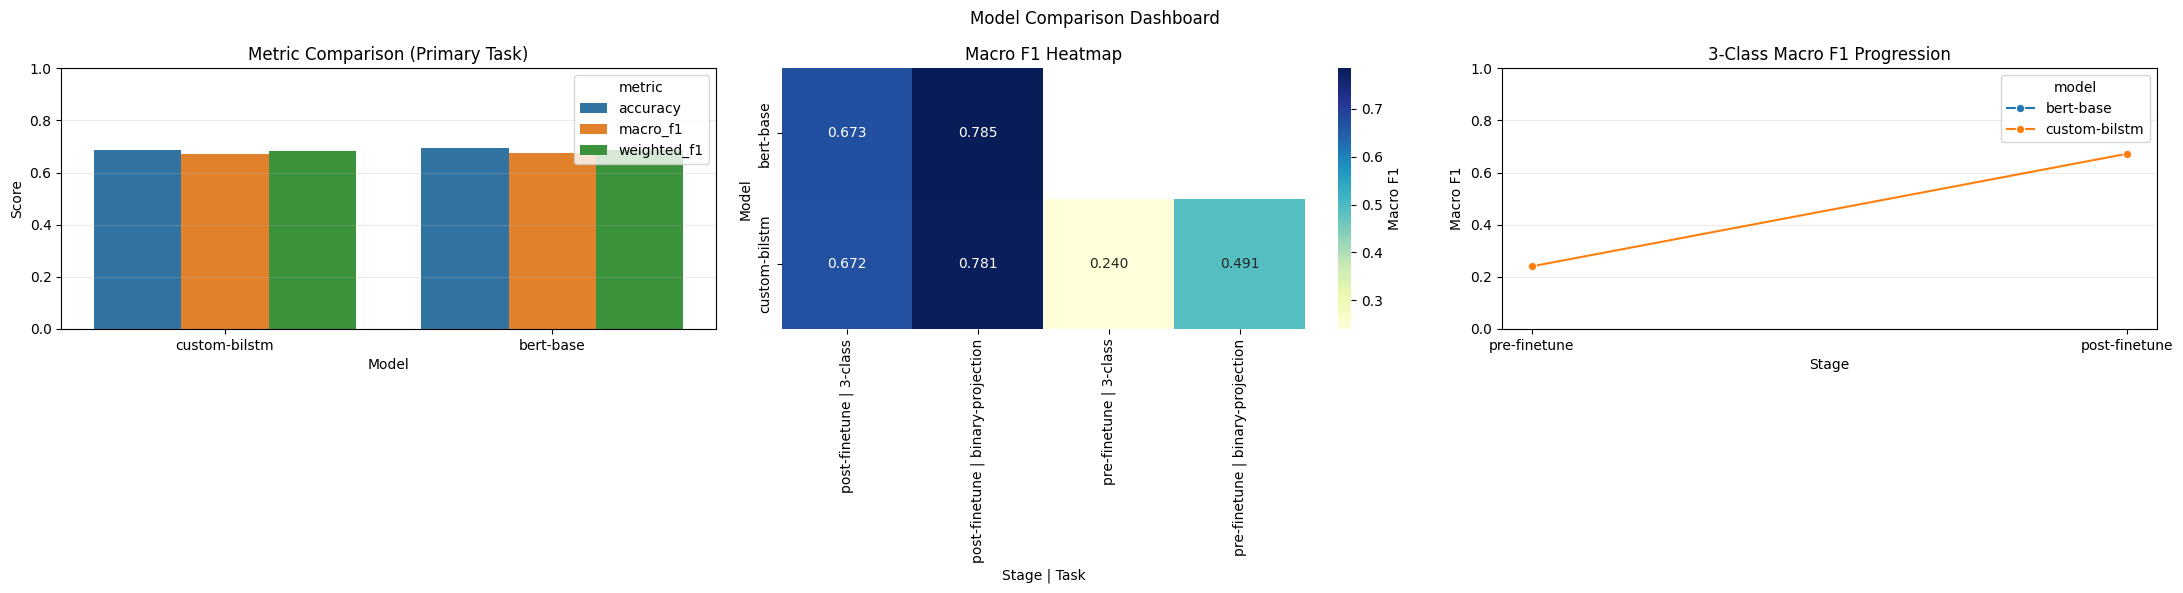

Saved comparison plots: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/model_comparison_plots.png
Saved comparison CSV: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/model_comparison_results.csv
Saved comparison JSON: /content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts/model_comparison_results.json


In [ ]:
# -------------------------
# BERT evaluation and final model comparison
# -------------------------
label_names = [ID_TO_LABEL[i] for i in range(3)]
bert_test_output = globals().get("bert_test_output", None)
bert_report_df = globals().get("bert_report_df", None)
bert_model = globals().get("bert_model", None)
bert_tokenizer = globals().get("bert_tokenizer", None)
samples = globals().get("samples", [])

if RUN_BERT and bert_test_output is not None:
    bert_preds = np.argmax(bert_test_output.predictions, axis=-1)
    bert_true = bert_test_output.label_ids

    bert_3class_metrics = evaluate_label_predictions(
        y_true=bert_true,
        y_pred=bert_preds,
        label_names=label_names,
        title=f"{MODEL_NAME_BERT} Post-Finetune on HateXplain (3-Class)",
        cmap="Greens",
    )
    upsert_experiment_result(
        MODEL_NAME_BERT,
        "post-finetune",
        "3-class",
        bert_3class_metrics,
    )

    bert_report_df = pd.DataFrame(bert_3class_metrics["classification_report"]).T
    print("\nBERT per-class report:")
    print(bert_report_df)

    bert_post_binary_metrics = evaluate_label_predictions(
        y_true=project_hatexplain_to_binary(bert_true),
        y_pred=project_hatexplain_to_binary(bert_preds),
        label_names=[BINARY_ID_TO_LABEL[i] for i in range(2)],
        title=f"{MODEL_NAME_BERT} Post-Finetune on HateXplain (Binary Projection)",
        cmap="Oranges",
    )
    upsert_experiment_result(
        MODEL_NAME_BERT,
        "post-finetune",
        "binary-projection",
        bert_post_binary_metrics,
    )

    bert_report_path = ARTIFACT_DIR / "bert_post_report.json"
    with open(bert_report_path, "w", encoding="utf-8") as fp:
        json.dump(bert_3class_metrics["classification_report"], fp, indent=2)
    bert_report_csv_path = ARTIFACT_DIR / "bert_post_report.csv"
    bert_report_df.to_csv(bert_report_csv_path)
    print(f"Saved BERT report: {bert_report_path}")
    print(f"Saved BERT report CSV: {bert_report_csv_path}")

    if samples and bert_model is not None and bert_tokenizer is not None:
        def predict_bert_text(text: str):
            bert_model.eval()
            inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, max_length=BERT_MAX_LEN)
            inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
            bert_model.to(DEVICE)
            with torch.no_grad():
                logits = bert_model(**inputs).logits
                probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            pred_id = int(np.argmax(probs))
            return {
                "text": text,
                "predicted_label": ID_TO_LABEL[pred_id],
                "probabilities": {ID_TO_LABEL[i]: float(probs[i]) for i in range(len(probs))},
            }

        print("\nBERT sample predictions:")
        for s in samples:
            print(predict_bert_text(s))
else:
    print("RUN_BERT is False or BERT outputs are unavailable. Skipping BERT evaluation.")

comparison_df = build_comparison_df()
if comparison_df.empty:
    print("No model results are logged yet.")
else:
    comparison_view = comparison_df[["model", "stage", "task", "accuracy", "macro_f1", "weighted_f1"]].copy()
    print("\nModel comparison:")
    print(comparison_view)

    comparison_export = comparison_view.copy()
    comparison_export["model"] = comparison_export["model"].astype(str)
    comparison_export["stage"] = comparison_export["stage"].astype(str)

    comparison_csv_path = ARTIFACT_DIR / "model_comparison_results.csv"
    comparison_json_path = ARTIFACT_DIR / "model_comparison_results.json"
    comparison_export.to_csv(comparison_csv_path, index=False)
    with open(comparison_json_path, "w", encoding="utf-8") as fp:
        json.dump(comparison_export.to_dict(orient="records"), fp, indent=2)

    print(f"Saved comparison CSV: {comparison_csv_path}")
    print(f"Saved comparison JSON: {comparison_json_path}")

## Notes

- This notebook is designed for GPU-enabled environments such as Colab.
- In Colab, run the Drive-mount cell so checkpoints and artifacts are saved to `/content/drive/MyDrive/UM/Colab Notebooks/nlp_proj_artifacts`.
- If Sentiment140 download fails, configure Kaggle credentials and rerun the data-loading cell.
- GloVe matrices are cached under the artifact folder so repeated runs do not re-download/rebuild embeddings.
- `LOAD_STAGE1_ENCODER = False` lets you compare a GloVe-only custom model against transfer variants.
- `RUN_BERT = True` enables a transformer comparison model on the same HateXplain splits.